In [1]:
%matplotlib notebook

import numpy as np
import json
import math
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
#from numpy.random import seed 
#seed(2)
#tf.random.set_seed(9)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU,Dense, Dropout, Flatten, Input, BatchNormalization, Reshape, UpSampling1D, Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam,RMSprop
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K 

import seaborn as sns

from sklearn.preprocessing import MinMaxScaler,Binarizer

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score,f1_score

In [2]:
fp_list = ['combine']

class Data():
    
    def __init__(self, fp, pos_neg):
        
        self.fp = fp
        self.pos_neg = pos_neg
        
        if self.pos_neg == 'pos':
            self.load_pos_data()
            self.shuffle()
            
        elif self.pos_neg == 'neg':
            self.load_neg_data()
            self.shuffle()
    

    def load_pos_data(self):
        with open('{}.json'.format(self.fp), 'r') as file:
            temp = json.load(file)
        positive_index = [i for i in range(len(temp['y'])) if temp['y'][i] == [1,0]]
        self.y = np.array([temp['y'][i] for i in positive_index])
        self.x = np.array([temp['x'][i] for i in positive_index])
        self.x = self.x.reshape(self.x.shape[0], self.x.shape[1],1)
        self.z = self.x.reshape(self.x.shape[0], self.x.shape[1])
        self.m = len(positive_index)
        self.n = self.x.shape[1]
        print('Shape x: {}'.format(self.x.shape))
        print('Shape y: {}'.format(self.y.shape))
    
    def load_neg_data(self):
        with open('{}.json'.format(self.fp), 'r') as file:
            temp = json.load(file)
        negative_index = [i for i in range(len(temp['y'])) if temp['y'][i] == [0,1]]
        self.y = np.array([temp['y'][i] for i in negative_index])
        self.x = np.array([temp['x'][i] for i in negative_index])
        self.x = self.x.reshape(self.x.shape[0], self.x.shape[1],1)
        self.z = self.x.reshape(self.x.shape[0], self.x.shape[1])
        self.m = len(negative_index)
        self.n = self.x.shape[1]
        print('Shape x: {}'.format(self.x.shape))
        print('Shape y: {}'.format(self.y.shape))
    
    def shuffle(self):
        temp_x = np.zeros(self.x.shape)
        index = list(range(self.m))
        np.random.shuffle(index)
        for x in range(self.m):
            value = int(index[int(x)])
            temp_x[x,:] = self.x[value,:]
        self.x = temp_x
                                  
    def convert(self, string, as_array=True):
        letter_list = list('abcdef')
        jump = 1
        fp = []
        code = [0]*len(list(string))*4
        for index in range(len(list(string))):
            index += jump
            value = string[index].lower()
            if value in letter_list:
                value = letter_list.index(value) + 10
            index = (index-jump)*4
            value = int(value)
            code[index] = 1*value%2
            code[index+1] = 1*math.floor(value/2)%2
            code[index+2] = 1*math.floor(value/4)%2
            code[index+3] = 1*math.floor(value/8)%2
            jump *= -1
        if as_array == True:
            code = np.array(code)
        return code

In [3]:
pos_data=Data(fp='combine', pos_neg='pos')
neg_data=Data(fp='combine', pos_neg='neg')

Shape x: (7002, 168, 1)
Shape y: (7002, 2)
Shape x: (9998, 168, 1)
Shape y: (9998, 2)


In [4]:
batch_size=7002
    #get real compounds
    #index = np.random.choice(range(pos_data.m), size=(batch_size), replace=False)
train_x_real = pos_data.x
train_y_real = np.zeros([batch_size,2])
train_y_real[:,0] = 1
    #d_loss_real = d.train_on_batch(train_x_real,train_y_real)

    #get decoys
index1 = np.random.choice(range(neg_data.m), size=(batch_size), replace=False)
train_x_decoy = neg_data.x[index1]
train_y_decoy = np.zeros([batch_size,2])
train_y_decoy[:,1] = 1
    #d_loss_decoy = d.train_on_batch(train_x_real,train_y_real)

    # d_loss = d_loss_real + d_loss_decoy
    # loss_d_epoch.append(d_loss[0])
X = np.concatenate((train_x_real, train_x_decoy))
y = np.zeros([2*batch_size,2])
y[0:(batch_size),0] = 1
y[(batch_size):,1] = 1
    
df_y = pd.DataFrame(y)
y_new = df_y.iloc[:,0]

In [5]:
cv = StratifiedKFold(n_splits=10)

In [6]:
def calc_precision(y_true, y_pred):
    true_pos = calc_true_positive(y_true, y_pred)
    return true_pos/np.sum(y_pred, axis=0)

def calc_recall(y_true, y_pred):
    true_pos = calc_true_positive(y_true, y_pred)
    return true_pos/np.sum(y_true, axis=0)

def calc_true_positive(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply(y_true,y_pred), axis=0)
    else:
        return tf.reduce_sum(y_true*y_pred)

def calc_true_negative(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_true),(1-y_pred)), axis=0)
    else:
        return tf.reduce_sum((1-y_true)*(1-y_pred))

def calc_false_positive(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_true),(y_pred)), axis=0)
    else:
        return tf.reduce_sum((1-y_true)*y_pred)

def calc_false_negative(y_true, y_pred):
    if type(y_pred) == np.ndarray:
        return np.sum(np.multiply((1-y_pred),y_true), axis=0)
    else:
        return tf.reduce_sum(y_true*(1-y_pred))

In [ ]:
mean_fpr = np.linspace(0, 1, 100)
tprs=[]
tprs_all=[]
fprs=[]
aucs=[]
accs=[]
f1s=[]
TPs=[]
TNs=[]
FPs=[]
FNs=[]
precisions=[]
recalls=[]

for train,test in cv.split(X,y_new):

    
    model = Sequential()
    model.add(Conv1D(8, kernel_size=3,
                     strides=1,
                     activation='relu',
                     padding='valid',
                     input_shape=[168,1],
                     kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(16, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(32, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))

    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same'))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv1D(64, kernel_size=3, activation= 'relu', strides=1, padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
    model.add(Dropout(0.5))
    model.add(Flatten())

    model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Dense(2, activation='softmax', kernel_regularizer=regularizers.l2(0.01)))

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=keras.optimizers.Adam(lr=0.00045),
                  metrics=['accuracy'])



    model.fit(X[train],y[train],
                 batch_size=batch_size,
                 epochs=80,
                 verbose=1,
                 validation_data=(X[test],y[test]))
    
    pred_prob = model.predict(X[test])[:,0]
    pred = model.predict(X[test])[:,0]
    y_pred = np.round(pred)
    print(y_pred)
    print(pred_prob)
    fpr, tpr, thresholds = roc_curve(y_new[test],pred_prob)
    roc_auc = auc(fpr,tpr)
    fprs.append(fpr)
    tprs.append(tpr)
    aucs.append(roc_auc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs_all.append(interp_tpr)

    acc = accuracy_score(y_new[test], y_pred)
    f1 = f1_score(y_new[test], y_pred)
    accs.append(acc)
    f1s.append(f1)
    
    TP=calc_true_positive(y_new[test], y_pred)
    TN=calc_true_negative(y_new[test], y_pred)
    FP=calc_false_positive(y_new[test], y_pred)
    FN=calc_false_negative(y_new[test], y_pred)
    TPs.append(TP)
    TNs.append(TN)
    FPs.append(FP)
    FNs.append(FN)

    prec = calc_precision(y_new[test], y_pred)
    recall=calc_recall(y_new[test],y_pred)

    precisions.append(prec)
    recalls.append(recall)
    
    del model
    K.clear_session()


Epoch 1/80
2/2 [==============================] - 2s 1s/step - loss: 9.4383 - accuracy: 0.4992 - val_loss: 9.2798 - val_accuracy: 0.5004
Epoch 2/80
2/2 [==============================] - 1s 580ms/step - loss: 9.2346 - accuracy: 0.5201 - val_loss: 9.0790 - val_accuracy: 0.5004
Epoch 3/80
2/2 [==============================] - 1s 583ms/step - loss: 9.0345 - accuracy: 0.5331 - val_loss: 8.8815 - val_accuracy: 0.5004
Epoch 4/80
2/2 [==============================] - 1s 629ms/step - loss: 8.8377 - accuracy: 0.5465 - val_loss: 8.6875 - val_accuracy: 0.5004
Epoch 5/80
2/2 [==============================] - 1s 621ms/step - loss: 8.6444 - accuracy: 0.5453 - val_loss: 8.4972 - val_accuracy: 0.5004
Epoch 6/80
2/2 [==============================] - 1s 328ms/step - loss: 8.4549 - accuracy: 0.5477 - val_loss: 8.3104 - val_accuracy: 0.5004
Epoch 7/80
2/2 [==============================] - 1s 315ms/step - loss: 8.2688 - accuracy: 0.5474 - val_loss: 8.1272 - val_accuracy: 0.5004
Epoch 8/80
2/2 [=======

2/2 [==============================] - 2s 980ms/step - loss: 4.4324 - accuracy: 0.5601 - val_loss: 4.3593 - val_accuracy: 0.5004
Epoch 36/80
2/2 [==============================] - 2s 965ms/step - loss: 4.3370 - accuracy: 0.5677 - val_loss: 4.2655 - val_accuracy: 0.5004
Epoch 37/80
2/2 [==============================] - 2s 927ms/step - loss: 4.2437 - accuracy: 0.5684 - val_loss: 4.1740 - val_accuracy: 0.5004
Epoch 38/80
2/2 [==============================] - 2s 971ms/step - loss: 4.1526 - accuracy: 0.5698 - val_loss: 4.0849 - val_accuracy: 0.5004
Epoch 39/80
2/2 [==============================] - 2s 1s/step - loss: 4.0640 - accuracy: 0.5680 - val_loss: 3.9979 - val_accuracy: 0.5004
Epoch 40/80
2/2 [==============================] - 2s 962ms/step - loss: 3.9777 - accuracy: 0.5590 - val_loss: 3.9131 - val_accuracy: 0.5004
Epoch 41/80
2/2 [==============================] - 2s 1s/step - loss: 3.8931 - accuracy: 0.5592 - val_loss: 3.8302 - val_accuracy: 0.5004
Epoch 42/80
2/2 [==============

2/2 [==============================] - 2s 1s/step - loss: 7.2081 - accuracy: 0.5747 - val_loss: 7.0882 - val_accuracy: 0.4996
Epoch 14/80
2/2 [==============================] - 2s 775ms/step - loss: 7.0471 - accuracy: 0.5757 - val_loss: 6.9311 - val_accuracy: 0.4996
Epoch 15/80
2/2 [==============================] - 1s 750ms/step - loss: 6.8903 - accuracy: 0.5747 - val_loss: 6.7775 - val_accuracy: 0.4996
Epoch 16/80
2/2 [==============================] - 2s 1s/step - loss: 6.7364 - accuracy: 0.5758 - val_loss: 6.6275 - val_accuracy: 0.4996
Epoch 17/80
2/2 [==============================] - 2s 884ms/step - loss: 6.5864 - accuracy: 0.5794 - val_loss: 6.4808 - val_accuracy: 0.4996
Epoch 18/80
2/2 [==============================] - 2s 914ms/step - loss: 6.4395 - accuracy: 0.5787 - val_loss: 6.3373 - val_accuracy: 0.4996
Epoch 19/80
2/2 [==============================] - 2s 950ms/step - loss: 6.2957 - accuracy: 0.5864 - val_loss: 6.1971 - val_accuracy: 0.4996
Epoch 20/80
2/2 [==============

2/2 [==============================] - 2s 916ms/step - loss: 3.3426 - accuracy: 0.5739 - val_loss: 3.2942 - val_accuracy: 0.4996
Epoch 49/80
2/2 [==============================] - 1s 708ms/step - loss: 3.2737 - accuracy: 0.5750 - val_loss: 3.2271 - val_accuracy: 0.4996
Epoch 50/80
2/2 [==============================] - 1s 738ms/step - loss: 3.2057 - accuracy: 0.5820 - val_loss: 3.1612 - val_accuracy: 0.4996
Epoch 51/80
2/2 [==============================] - 2s 836ms/step - loss: 3.1402 - accuracy: 0.5781 - val_loss: 3.0966 - val_accuracy: 0.4996
Epoch 52/80
2/2 [==============================] - 2s 890ms/step - loss: 3.0766 - accuracy: 0.5753 - val_loss: 3.0342 - val_accuracy: 0.4996
Epoch 53/80
2/2 [==============================] - 2s 772ms/step - loss: 3.0133 - accuracy: 0.5827 - val_loss: 2.9741 - val_accuracy: 0.4996
Epoch 54/80
2/2 [==============================] - 2s 789ms/step - loss: 2.9524 - accuracy: 0.5866 - val_loss: 2.9148 - val_accuracy: 0.4996
Epoch 55/80
2/2 [========

2/2 [==============================] - 1s 621ms/step - loss: 9.2283 - accuracy: 0.5019 - val_loss: 9.0720 - val_accuracy: 0.5000
Epoch 3/80
2/2 [==============================] - 2s 803ms/step - loss: 9.0282 - accuracy: 0.4923 - val_loss: 8.8747 - val_accuracy: 0.5000
Epoch 4/80
2/2 [==============================] - 2s 776ms/step - loss: 8.8315 - accuracy: 0.4929 - val_loss: 8.6809 - val_accuracy: 0.5000
Epoch 5/80
2/2 [==============================] - 1s 706ms/step - loss: 8.6383 - accuracy: 0.4961 - val_loss: 8.4905 - val_accuracy: 0.5000
Epoch 6/80
2/2 [==============================] - 1s 727ms/step - loss: 8.4488 - accuracy: 0.5028 - val_loss: 8.3038 - val_accuracy: 0.5000
Epoch 7/80
2/2 [==============================] - 2s 871ms/step - loss: 8.2628 - accuracy: 0.5048 - val_loss: 8.1207 - val_accuracy: 0.5529
Epoch 8/80
2/2 [==============================] - 1s 740ms/step - loss: 8.0804 - accuracy: 0.5136 - val_loss: 7.9413 - val_accuracy: 0.5000
Epoch 9/80
2/2 [===============

2/2 [==============================] - 1s 735ms/step - loss: 4.2147 - accuracy: 0.5852 - val_loss: 4.1481 - val_accuracy: 0.5000
Epoch 38/80
2/2 [==============================] - 2s 799ms/step - loss: 4.1245 - accuracy: 0.5805 - val_loss: 4.0599 - val_accuracy: 0.5000
Epoch 39/80
2/2 [==============================] - 2s 752ms/step - loss: 4.0365 - accuracy: 0.5757 - val_loss: 3.9735 - val_accuracy: 0.5000
Epoch 40/80
2/2 [==============================] - 2s 795ms/step - loss: 3.9503 - accuracy: 0.5771 - val_loss: 3.8889 - val_accuracy: 0.5000
Epoch 41/80
2/2 [==============================] - 1s 700ms/step - loss: 3.8663 - accuracy: 0.5847 - val_loss: 3.8067 - val_accuracy: 0.5000
Epoch 42/80
2/2 [==============================] - 2s 771ms/step - loss: 3.7843 - accuracy: 0.5903 - val_loss: 3.7267 - val_accuracy: 0.5000
Epoch 43/80
2/2 [==============================] - 1s 651ms/step - loss: 3.7046 - accuracy: 0.5850 - val_loss: 3.6488 - val_accuracy: 0.5000
Epoch 44/80
2/2 [========

2/2 [==============================] - 2s 819ms/step - loss: 2.0755 - accuracy: 0.6070 - val_loss: 2.0730 - val_accuracy: 0.5150
Epoch 73/80
2/2 [==============================] - 2s 757ms/step - loss: 2.0374 - accuracy: 0.6017 - val_loss: 2.0437 - val_accuracy: 0.5093
Epoch 74/80
2/2 [==============================] - 1s 749ms/step - loss: 1.9999 - accuracy: 0.6074 - val_loss: 1.9933 - val_accuracy: 0.5193
Epoch 75/80
2/2 [==============================] - 2s 801ms/step - loss: 1.9655 - accuracy: 0.6081 - val_loss: 1.9609 - val_accuracy: 0.5229
Epoch 76/80
2/2 [==============================] - 2s 849ms/step - loss: 1.9294 - accuracy: 0.6102 - val_loss: 1.9362 - val_accuracy: 0.5186
Epoch 77/80
2/2 [==============================] - 2s 889ms/step - loss: 1.8991 - accuracy: 0.5972 - val_loss: 1.8910 - val_accuracy: 0.5300
Epoch 78/80
2/2 [==============================] - 2s 783ms/step - loss: 1.8631 - accuracy: 0.6081 - val_loss: 1.8565 - val_accuracy: 0.5379
Epoch 79/80
2/2 [========

2/2 [==============================] - 2s 767ms/step - loss: 5.3858 - accuracy: 0.5801 - val_loss: 5.2957 - val_accuracy: 0.5000
Epoch 27/80
2/2 [==============================] - 1s 720ms/step - loss: 5.2675 - accuracy: 0.5778 - val_loss: 5.1796 - val_accuracy: 0.5000
Epoch 28/80
2/2 [==============================] - 2s 830ms/step - loss: 5.1520 - accuracy: 0.5800 - val_loss: 5.0663 - val_accuracy: 0.5000
Epoch 29/80
2/2 [==============================] - 2s 799ms/step - loss: 5.0392 - accuracy: 0.5825 - val_loss: 4.9558 - val_accuracy: 0.5000
Epoch 30/80
2/2 [==============================] - 1s 706ms/step - loss: 4.9291 - accuracy: 0.5849 - val_loss: 4.8480 - val_accuracy: 0.5000
Epoch 31/80
2/2 [==============================] - 2s 762ms/step - loss: 4.8216 - accuracy: 0.5841 - val_loss: 4.7426 - val_accuracy: 0.5000
Epoch 32/80
2/2 [==============================] - 1s 692ms/step - loss: 4.7167 - accuracy: 0.5788 - val_loss: 4.6398 - val_accuracy: 0.5000
Epoch 33/80
2/2 [========

<IPython.core.display.Javascript object>


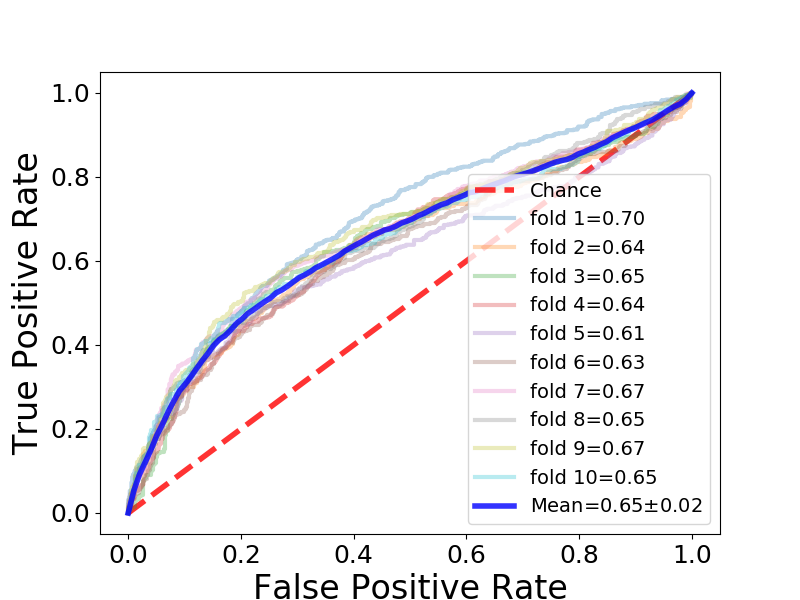

In [8]:
fig, ax = plt.subplots(figsize = (8,6))

ax.plot([0, 1], [0, 1], linestyle='--', color='r',
        label='Chance', alpha=.8, linewidth = 4)

for j in range(10):
    ax.plot(fprs[j], tprs[j], label='fold {0}={1:0.2f}'.format(j+1, aucs[j]), alpha=0.3, linewidth = 3)

mean_fpr = np.linspace(0, 1, 100)
mean_tpr = np.mean(tprs_all, axis=0)
mean_tpr[-1] = 1.0
mean_auc_svm = auc(mean_fpr, mean_tpr)
std_auc_svm = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean=%0.2f$\pm$%0.2f' % (mean_auc_svm, std_auc_svm),
        alpha=.8, linewidth = 4)

std_tpr = np.std(tprs_all, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
#ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
#                label=r'$\pm$ 1 std. dev.')
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05])

ax.legend(loc="lower right")

plt.xlabel('False Positive Rate', fontsize=24)
plt.ylabel('True Positive Rate', fontsize=24)
plt.legend(loc="lower right", prop={"size":14})
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.savefig('maccs_D_vggnet11.pdf',dpi=600)
plt.show()